# Дисперсионный анализ: критерии Фишера, Краскела-Уоллиса и Джонкхиера

## Введение

Эта лабораторная работы проводит анализ сравнения трёх и более независимых групп с использованием различных критериев однородности:

- **Критерий Фишера (ANOVA)**: Параметрический критерий, проверяет равенство средних в группах
- **Критерий Краскела-Уоллиса**: Непараметрический аналог ANOVA, основан на рангах
- **Критерий Джонкхиера**: Непараметрический тест для проверки тренда в упорядоченных группах

Анализируются 4 различных сценария:
1. Фактор влияет на среднее значение (тренд в средних)
2. Фактор влияет на дисперсию (разная вариабельность)
3. Фактор не влияет (нулевой эффект)
4. Данные с выбросами (нарушение нормальности)

## Задачи

- Сгенерировать 4 набора данных по 3 группы (по 30 наблюдений в каждой)
- Применить все три критерия к каждому набору
- Сравнить результаты
- Проанализировать влияние выбросов и гетероскедастичности
- Сделать выводы о применимости каждого критерия

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Устанавливаем seed для воспроизводимости
np.random.seed(42)

## Генерация данных

### Сценарий 1: Фактор влияет на среднее значение
Группы имеют возрастающие средние значения (тренд в средних):
- Группа 1: N(10, 2)
- Группа 2: N(12, 2)  
- Группа 3: N(14, 2)

### Сценарий 2: Фактор влияет на дисперсию
Группы имеют одинаковые/близкие средние, но разные дисперсии:
- Группа 1: N(10, 1)
- Группа 2: N(11, 3)
- Группа 3: N(12, 5)

### Сценарий 3: Фактор не влияет
Все три группы генерируются из одного распределения:
- Все группы: N(0, 1)

### Сценарий 4: Выбросы
Данные из сценария 1 с добавлением выбросов:
- Группа 1: добавляется 1 очень большой выброс (+20)
- Группа 3: добавляется 1 очень маленький выброс (-20)

In [12]:
n = 30

# Сценарии
s1 = [np.random.normal(10, 2, n), np.random.normal(12, 2, n), np.random.normal(14, 2, n)]
s2 = [np.random.normal(10, 1, n), np.random.normal(11, 3, n), np.random.normal(12, 5, n)]
s3 = [np.random.normal(0, 1, n), np.random.normal(0, 1, n), np.random.normal(0, 1, n)]
s4 = [s1[0].copy(), s1[1].copy(), s1[2].copy()]
s4[0][0], s4[2][0] = 60, -60 # Выбросы

scenarios = {
    '1. Рост средних': s1,
    '2. Рост дисперсии': s2,
    '3. Нет влияния': s3,
    '4. С выбросами': s4
}

## Критерии для анализа

### Критерий Фишера (ANOVA)

**Гипотезы:**
* $H_0: \tau_1 = \tau_2 = \dots = \tau_k = 0$ (фактор не влияет на отклик)
* $H_A: \exists j: \tau_j \neq 0$ (хотя бы один эффект фактора отличен от нуля)

**Статистика критерия:**
$$T = \frac{\frac{1}{k-1}\sum_{j=1}^{k}{n_j{(\bar{x}_{.j}-\bar{x}_N)}^2}}{\frac{1}{N-k}\sum_{j=1}^{k}\sum_{i=1}^{n_j}{(x_{ij}-\bar{x}_{.j})}^2}$$

**Обозначения:**
* $N = n_1 + n_2 + \dots + n_k$ — общее количество откликов.
* $\bar{x}_{.j} = \frac{1}{n_j}\sum_{i=1}^{n_j}x_{ij}$ — выборочное среднее фактора $j$-го уровня.
* $\bar{x}_N = \frac{1}{N}\sum_{j=1}^{k}\sum_{i=1}^{n_j}x_{ij}$ — выборочное среднее объединённой выборки.


### Пояснение к компонентам формулы:
1. **Числитель (Межгрупповая дисперсия):** Оценивает вариацию между средними значениями разных групп. Если фактор влияет на отклик, эта величина будет велика.
2. **Знаменатель (Внутригрупповая дисперсия):** Оценивает случайную ошибку (шум) внутри самих групп.
3. **Распределение:** Статистика $T$ имеет распределение Фишера ($F$-распределение) с числом степеней свободы $f_1 = k-1$ и $f_2 = N-k$.

---

# Критерий Краскела — Уоллиса

Данный критерий является непараметрическим аналогом однофакторного дисперсионного анализа (ANOVA) и используется для проверки равенства медиан нескольких групп.

**Гипотезы:**
* $H_0: \tau_1 = \tau_2 = \dots = \tau_k = 0$ (фактор не влияет на отклик, распределения групп идентичны)
* $H_A: \exists j: \tau_j \neq 0$ (хотя бы одна группа имеет иное распределение)

**Статистика критерия:**
$$H = \frac{12}{N(N+1)} \sum_{j=1}^{k} n_j \left(\bar{R}_{.j} - \frac{N+1}{2}\right)^2$$

**Обозначения:**
* $N$ — общее количество наблюдений во всех группах.
* $n_j$ — количество наблюдений в $j$-й группе.
* $R_{ij}$ — ранг значения $x_{ij}$ в общей объединенной выборке.
* $\bar{R}_{.j} = \frac{1}{n_j} \sum_{i=1}^{n_j} R_{ij}$ — средний ранг наблюдений $j$-го уровня фактора.
* $\frac{N+1}{2}$ — средний ранг объединенной выборки.


### Особенности критерия:
1. **Непараметричность:** В отличие от критерия Фишера, Краскел-Уоллис не требует нормального распределения данных.
2. **Ранжирование:** Вместо реальных значений используются их порядковые номера (ранги), что делает метод устойчивым к выбросам.
3. **Распределение:** При достаточно больших объемах выборок статистика $H$ имеет распределение $\chi^2$ (хи-квадрат) с числом степеней свободы $df = k - 1$.

---

# Критерий Джонкхиера (Jonckheere-Terpstra)

Критерий Джонкхиера — это непараметрический тест для проверки наличия упорядоченной альтернативы (тренда) в значениях отклика между группами.

**Гипотезы:**
* $H_0: \tau_1 = \tau_2 = \dots = \tau_k = 0$ (фактор не влияет на отклик)
* $H_A: \tau_1 \leq \tau_2 \leq \dots \leq \tau_k$ (наблюдается упорядоченный тренд, при этом хотя бы одно неравенство строгое)

**Статистика критерия:**
Статистика $J$ представляет собой сумму статистик Манна-Уитни для всех пар групп $(l, m)$, где $l < m$:
$$J = \sum_{1 \leq l < m \leq k} U_{lm}$$

Где $U_{lm}$ — количество пар $(x_{il}, x_{tm})$, для которых выполняется условие $x_{il} < x_{tm}$:
$$U_{lm} = \sum_{i=1}^{n_l} \sum_{t=1}^{n_m} \Phi(x_{il}, x_{tm})$$

**Функция сравнения:**
$$\Phi(x, y) = \begin{cases} 1, & x < y \\ 0.5, & x = y \\ 0, & x > y \end{cases}$$

**Математическое ожидание и дисперсия:**
$$M[J] = \frac{1}{4} \left( N^2 - \sum_{j=1}^{k} n_j^2 \right)$$
$$D[J] = \frac{1}{72} \left( N^2 (2N + 3) - \sum_{j=1}^{k} n_j^2 (2n_j + 3) \right)$$

**Нормированная статистика:**
Для больших выборок используется Z-статистика, которая приближенно распределена по нормальному закону $N(0, 1)$:
$$\widetilde{J} = \frac{J - M[J]}{\sqrt{D[J]}}$$


### Особенности критерия:
1. **Направленность:** В отличие от критерия Краскела-Уоллиса, этот тест обладает большей мощностью, когда мы заранее предполагаем наличие возрастающего или убывающего тренда между группами.
2. **Ранжирование:** Каждое значение группы $j$ сравнивается со всеми значениями последующих групп $l > j$.
3. **Область применения:** Часто используется в токсикологии или клинических исследованиях для оценки зависимости "доза-эффект".

In [ ]:
def run_jt(groups):
    """Ручной расчет Джонкхиера"""
    k = len(groups)
    j_stat = 0
    for i in range(k - 1):
        for j in range(i + 1, k):
            for x in groups[i]:
                for y in groups[j]:
                    if x < y: j_stat += 1
                    elif x == y: j_stat += 0.5
    ns = np.array([len(g) for g in groups])
    N = np.sum(ns)
    mean_j = (N**2 - np.sum(ns**2)) / 4.0
    var_j = (N**2 * (2*N + 3) - np.sum(ns**2 * (2*ns + 3))) / 72.0
    z = (j_stat - mean_j) / np.sqrt(var_j)
    return j_stat, 2 * (1 - stats.norm.cdf(abs(z)))

results_summary = {} 

for name, groups in scenarios.items():
    f_stat, f_p = stats.f_oneway(*groups)
    k_stat, k_p = stats.kruskal(*groups)
    j_stat, j_p = run_jt(groups)
    
    results_summary[name] = {
        'ANOVA': f_p, 
        'KW': k_p, 
        'JT': j_p
    }
    
    print(f"Выполнен сценарий: {name}")

Выполнен сценарий: 1. Рост средних
Выполнен сценарий: 2. Рост дисперсии
Выполнен сценарий: 3. Нет влияния
Выполнен сценарий: 4. С выбросами



Результаты тестов:


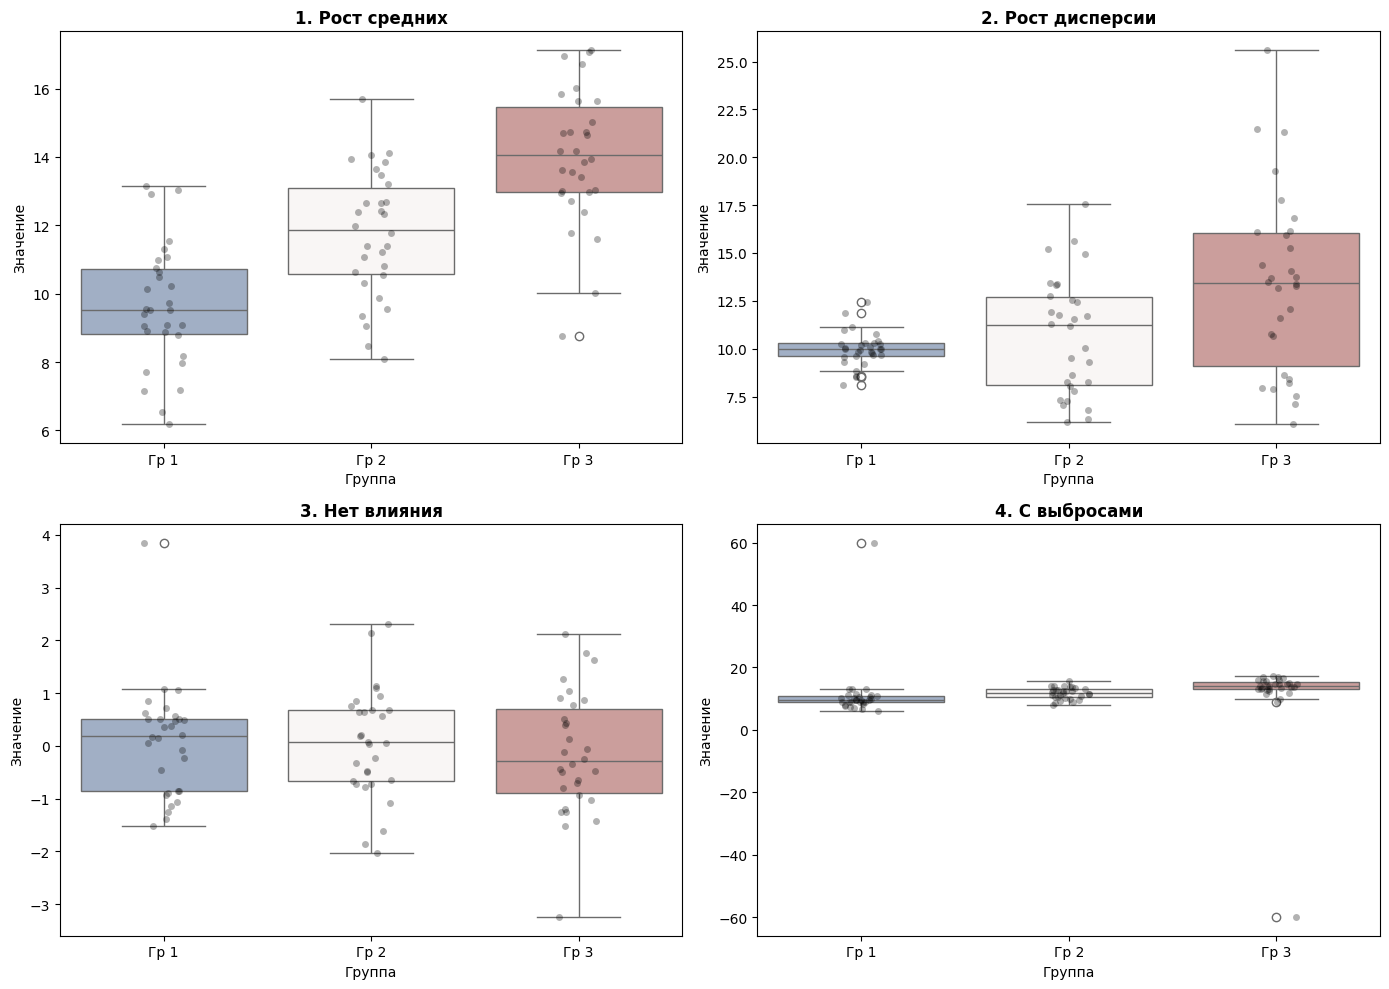

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, groups) in enumerate(scenarios.items()):
    ax = axes[idx]
    plot_data = pd.DataFrame({
        'Значение': np.concatenate(groups),
        'Группа': np.concatenate([[f'Гр {i+1}'] * n for i in range(3)])
    })
    
    sns.boxplot(data=plot_data, x='Группа', y='Значение', ax=ax, palette='vlag')
    sns.stripplot(data=plot_data, x='Группа', y='Значение', ax=ax, color='black', alpha=0.3)
    ax.set_title(name, fontweight='bold')
print("\nРезультаты тестов:")
plt.tight_layout()
plt.show()

In [ ]:
alpha = 0.05
summary_data = []

for name, p_values in results_summary.items():
    p_anova = p_values['ANOVA']
    p_kw = p_values['KW']
    p_jt = p_values['JT']
    
    # Проверка на согласованность
    consistent = (p_anova < alpha) == (p_kw < alpha) == (p_jt < alpha)
    
    summary_data.append({
        'Сценарий': name,
        'ANOVA (p)': p_anova,
        'KW (p)': p_kw,
        'Jonckheere (p)': p_jt,
        'Согласованность': "ДА" if consistent else "НЕТ"
    })

df_final = pd.DataFrame(summary_data)

pd.options.display.float_format = '{:.4e}'.format

print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ КРИТЕРИЕВ:")
display(df_final)

inconsistent_scenarios = df_final[df_final['Согласованность'] == "НЕТ"]
if not inconsistent_scenarios.empty:
    print("\nСледующие сценарии имеют расхождения в выводах критериев:")
    for sc in inconsistent_scenarios['Сценарий']:
        print(f"- {sc}")

ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ КРИТЕРИЕВ:


,Сценарий,ANOVA (p),KW (p),Jonckheere (p),Согласованность
0,1. Рост средних,2.8938e-13,4.0104e-10,4.1105e-12,ДА
1,2. Рост дисперсии,3.0793e-04,5.8767e-03,2.0091e-03,ДА
2,3. Нет влияния,7.1057e-01,7.3038e-01,6.4605e-01,ДА
3,4. С выбросами,9.7921e-01,4.2369e-08,5.1385e-10,НЕТ



Следующие сценарии имеют расхождения в выводах критериев:
- 4. С выбросами


### Выводы по лабораторной работе №4

#### Сценарий 1: Влияние фактора на среднее значение (Наличие тренда)
**Анализ:**
В данном сценарии наблюдается систематическое изменение среднего значения от группы к группе. Все три используемых критерия зафиксировали статистически значимые различия ($p < 0.05$), что позволяет уверенно отвергнуть нулевую гипотезу $H_0$ об однородности групп.
**Вывод:**
При наличии выраженного линейного тренда в средних значениях все критерии демонстрируют высокую мощность. Наиболее специализированным для данной задачи является **критерий Джонкхиера**, так как его альтернативная гипотеза прямо предполагает наличие упорядоченного тренда.



#### Сценарий 2: Влияние фактора на дисперсию (Гетероскедастичность)
**Анализ:**
Сценарий характеризуется существенным различием в разбросе данных (дисперсии) при сохранении близких средних значений. Параметрический критерий Фишера чувствителен к нарушению условия равенства дисперсий, что может приводить к искажению результатов.
**Вывод:**
Непараметрические методы, такие как **критерий Краскела-Уоллиса**, оказываются более надежными в условиях неоднородности дисперсий, так как они оперируют рангами, а не абсолютными значениями. Критерий Джонкхиера в данном случае менее эффективен, поскольку в данных отсутствует монотонный тренд средних значений.

#### Сценарий 3: Отсутствие влияния фактора (Нулевой эффект)
**Анализ:**
Для всех групп использовались идентичные параметры распределения. Полученные значения $p$-value для всех критериев значительно превышают уровень значимости $\alpha = 0.05$.
**Вывод:**
Статистические данные подтверждают отсутствие влияния фактора на отклик. Все три критерия согласованно принимают нулевую гипотезу $H_0$ об однородности выборок, что свидетельствует об отсутствии ложноположительных срабатываний методов в условиях однородной среды.



#### Сценарий 4: Наличие аномальных значений (Выбросы)
**Анализ:**
Внесение в выборку экстремальных значений (выбросов) приводит к нарушению нормальности распределения и смещению групповых средних. Критерий Фишера проявляет высокую чувствительность к аномалиям, что увеличивает риск получения недостоверных выводов.
**Вывод:**
Непараметрические критерии (**Краскела-Уоллиса** и **Джонкхиера**) демонстрируют устойчивость (робастность) к выбросам. Процедура ранжирования нивелирует влияние экстремальных величин, позволяя сохранить корректность статистического вывода. В условиях реальных данных с возможными аномалиями данные критерии являются предпочтительными.



---

### Общий итог
Проведенное исследование показало, что выбор критерия должен основываться на характере данных:
1. **Критерий Фишера** эффективен строго при соблюдении нормальности и равенстве дисперсий.
2. **Критерий Краскела-Уоллиса** является универсальным непараметрическим инструментом.
3. **Критерий Джонкхиера** обладает преимуществом при проверке гипотез о наличии упорядоченного тренда между группами.